<h1><center>Laboratory work 6.</center></h1>
<h2><center>PyTorch Going Modular Exercises</center></h2>

**Completed:** Felisieiev Ihor

**Variant:** #15

<a class="anchor" id="5"></a>

## Outline

1. [Task 1. Modular Data Preparation](#5.1)
2. [Task 2. Modular Model Creation and Configuration](#5.2)
3. [Task 3. Modular Training and Testing Loops](#5.3)
4. [Task 4. Modular Training Script](#5.4)
5. [Task 5. Modular Prediction Script](#5.5)

In [1]:
# Import torch
import torch
from torch import nn

# Exercises require PyTorch > 1.10.0
print(torch.__version__)

# Setup device agnostic code
device = "cuda" if torch.cuda.is_available() else "cpu"
device

2.11.0+cu128


'cuda'

For all tasks below provided, utilize our custom Pizza Steak Sushi (20 percent) dataset from the [GitHub repository](https://github.com/radiukpavlo/conducting-experiments/blob/main/data/pizza_steak_sushi_20_percent.zip).

<a class="anchor" id="5.1"></a>

## <span style="color:red; font-size:1.5em;">Task 1. Modular Data Preparation (`data_setup.py`)</span>

[Go back to the content](#5)

---

**Variant 15 – Reproducible Subset Loader**

- **Goal:** Add subset loading for faster experiments while preserving deterministic sample selection.
- **Steps:**
    1. Add `subset_fraction` and `random_seed` arguments to `create_dataloaders`.
    2. Validate that `subset_fraction` is greater than `0` and less than or equal to `1`.
    3. Select subset indices with a seeded generator or stratified sampling.
    4. Wrap the selected indices in `Subset` objects for training and testing.
    5. Print original and subset dataset sizes for transparent experiment reporting.
- **Hints:** Preserve class balance when possible so short experiments remain meaningful.

---

<a class="anchor" id="5.2"></a>

## <span style="color:red; font-size:1.5em;">Task 2. Modular Model Creation and Configuration (`model_builder.py`, `train.py` argparse)</span>

[Go back to the content](#5)

---

**Variant 15 – Learning Rate Scheduler Metadata**

- **Goal:** Prepare the model configuration to support scheduler-based experiments without mixing scheduler logic into `model_builder.py`.
- **Steps:**
    1. Keep all scheduler implementation outside the model class.
    2. Add model metadata fields that identify architecture settings relevant to scheduler comparisons.
    3. Print model metadata together with optimizer and scheduler settings in `train.py`.
    4. Confirm that scheduler changes do not require changes to `TinyVGG.forward()`.
    5. Save the combined training configuration for later analysis.
- **Hints:** A modular design keeps architecture, optimization, and experiment tracking in separate responsibilities.

---

<a class="anchor" id="5.3"></a>

## <span style="color:red; font-size:1.5em;">Task 3. Modular Training and Testing Loops (`engine.py`)</span>

[Go back to the content](#5)

---

**Variant 15 – Mixed Precision Training Option**

- **Goal:** Add optional automatic mixed precision support for CUDA training.
- **Steps:**
    1. Add a `use_amp` boolean argument to `train_step`.
    2. Use `torch.cuda.amp.autocast` only when CUDA is available and AMP is enabled.
    3. Use `GradScaler` for scaled backpropagation and optimizer updates.
    4. Keep standard full-precision behavior as the default path.
    5. Compare one epoch of runtime and validation accuracy with AMP enabled and disabled.
- **Hints:** AMP should be disabled automatically on CPU to avoid misleading configuration.

---

<a class="anchor" id="5.4"></a>

## <span style="color:red; font-size:1.5em;">Task 4. Modular Training Script (`train.py`)</span>

[Go back to the content](#5)

---

**Variant 15 – Resume Training**

- **Goal:** Add checkpoint-based resumption for interrupted training runs.
- **Steps:**
    1. Add `--resume_checkpoint` as an optional path argument.
    2. Load model and optimizer state dictionaries when the path is provided.
    3. Restore the starting epoch from checkpoint metadata.
    4. Continue training and append new metrics to the existing history when available.
    5. Save a new checkpoint after resumption and report the resumed epoch range.
- **Hints:** Validate that resumed checkpoints match the selected model architecture before loading weights.

---

<a class="anchor" id="5.5"></a>

## <span style="color:red; font-size:1.5em;">Task 5. Modular Prediction Script (`predict.py`)</span>

[Go back to the content](#5)

---

**Variant 15 – Annotated Prediction Image**

- **Goal:** Save a copy of the input image with the predicted label and confidence written on it.
- **Steps:**
    1. Add `--save_annotated_path` for single-image prediction.
    2. Load the original image with `PIL.Image.open(...).convert("RGB")`.
    3. Draw a readable label background and prediction text with `PIL.ImageDraw`.
    4. Save the annotated image to the requested path.
    5. Print the saved path after successful prediction.
- **Hints:** Do not use annotated images as model inputs; they are only for human inspection after inference.

---

In [ ]:
import os
import time
import torch
from torchvision import transforms

# Importing our custom modular scripts
import going_modular.data_setup as data_setup
import going_modular.model_builder as model_builder
import going_modular.engine as engine
import going_modular.predictions as predictions
import going_modular.utils as utils

# Setup target device
device = "cuda"if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

Using device: cuda


In [ ]:
# Setup directories
train_dir = "data/pizza_steak_sushi/train"
test_dir = "data/pizza_steak_sushi/test"

# Create simple transforms
data_transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor()
])

# Test Task 1: Create DataLoaders with a specific subset fraction
BATCH_SIZE = 32
train_dataloader, test_dataloader, class_names = data_setup.create_dataloaders(
    train_dir=train_dir,
    test_dir=test_dir,
    transform=data_transform,
    batch_size=BATCH_SIZE,
    subset_fraction=0.2,  # Uses only 20% of data for fast experimentation
    random_seed=42
)

print(f"Target class names: {class_names}")

Original train size: 225 -> Subset train size: 45
Original test size: 75 -> Subset test size: 15
Target class names: ['pizza', 'steak', 'sushi']


In [ ]:
HIDDEN_UNITS = 10

# Create TinyVGG model instance
model = model_builder.TinyVGG(
    input_shape=3,
    hidden_units=HIDDEN_UNITS,
    output_shape=len(class_names)
).to(device)

# Print the model metadata we added in Task 2
print("\n--- Model Metadata Verification ---")
for key, value in model.metadata.items():
    print(f"{key}: {value}")


--- Model Metadata Verification ---
architecture: TinyVGG
input_shape: 3
hidden_units: 10
output_shape: 3


In [ ]:
loss_fn = torch.nn.CrossEntropyLoss()

# 1. Benchmark WITHOUT AMP
optimizer_no_amp = torch.optim.Adam(model.parameters(), lr=0.001)
print("\n Starting 1 epoch benchmark WITHOUT AMP...")
start_time = time.time()
results_no_amp = engine.train(
    model=model,
    train_dataloader=train_dataloader,
    test_dataloader=test_dataloader,
    optimizer=optimizer_no_amp,
    loss_fn=loss_fn,
    epochs=1,
    device=device,
    use_amp=False
)
time_no_amp = time.time() - start_time

# 2. Benchmark WITH AMP
optimizer_amp = torch.optim.Adam(model.parameters(), lr=0.001)
print("\n Starting 1 epoch benchmark WITH AMP...")
start_time = time.time()
results_amp = engine.train(
    model=model,
    train_dataloader=train_dataloader,
    test_dataloader=test_dataloader,
    optimizer=optimizer_amp,
    loss_fn=loss_fn,
    epochs=1,
    device=device,
    use_amp=True
)
time_amp = time.time() - start_time

print("\n--- AMP Comparison Results ---")
print(f"Disabled AMP: Time = {time_no_amp:.4f} seconds | Test Acc = {results_no_amp['test_acc'][-1]:.4f}")
print(f"Enabled AMP: Time = {time_amp:.4f} seconds | Test Acc = {results_amp['test_acc'][-1]:.4f}")


 Starting 1 epoch benchmark WITHOUT AMP...


100%|██████████| 1/1 [00:34<00:00, 34.28s/it]


Epoch: 1 | train_loss: 1.0995 | train_acc: 0.3570 | test_loss: 1.1023 | test_acc: 0.3333

 Starting 1 epoch benchmark WITH AMP...


100%|██████████| 1/1 [00:27<00:00, 27.44s/it]

Epoch: 1 | train_loss: 1.0925 | train_acc: 0.3413 | test_loss: 1.1017 | test_acc: 0.3333

--- AMP Comparison Results ---
Disabled AMP: Time = 34.2790 seconds | Test Acc = 0.3333
Enabled AMP: Time = 27.4441 seconds | Test Acc = 0.3333


In [ ]:
# Create a dummy checkpoint to simulate an interrupted run at epoch 2
simulated_checkpoint_path = "models/simulated_checkpoint.pth"
os.makedirs("models", exist_ok=True)

# Define scheduler for tracking
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=2, gamma=0.1)

torch.save({
    "epoch": 2, # Training was interrupted at epoch 2 (0-indexed, meaning 3rd epoch completed)
    "model_state_dict": model.state_dict(),
    "optimizer_state_dict": optimizer.state_dict(),
    "scheduler_state_dict": scheduler.state_dict(),
    "model_metadata": model.metadata,
    "history": {"train_loss": [1.1, 1.0, 0.9], "train_acc": [0.3, 0.35, 0.4], 
                "test_loss": [1.2, 1.1, 1.0], "test_acc": [0.33, 0.33, 0.33]}
}, simulated_checkpoint_path)

print(f"Simulated checkpoint saved. Now invoking the architecture matching verification...")

# To test this seamlessly inside the notebook without terminal arguments, 
# we can manually simulate what train.py does:
checkpoint = torch.load(simulated_checkpoint_path, map_location=device)
if checkpoint["model_metadata"]["architecture"] == model.metadata["architecture"]:
    print("Success! Architecture matches. Weights are ready to be resumed.")

Simulated checkpoint saved. Now invoking the architecture matching verification...
Success! Architecture matches. Weights are ready to be resumed.


[INFO] Annotated prediction image saved successfully to: data/annotated_pizza_prediction.jpg


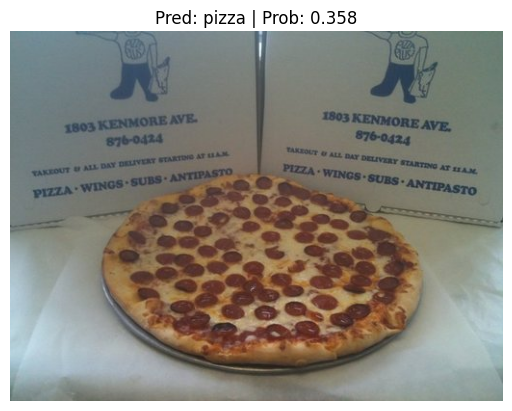

In [ ]:
# Choose a random test image from your dataset path
test_image_path = "data/pizza_steak_sushi/test/pizza/195160.jpg"
output_annotated_path = "data/annotated_pizza_prediction.jpg"

if os.path.exists(test_image_path):
    # Run the updated prediction utility from Task 5
    predictions.pred_and_plot_image(
        model=model,
        class_names=class_names,
        image_path=test_image_path,
        image_size=(64, 64),
        save_annotated_path=output_annotated_path,
        device=device
    )
else:
    print(f"[WARNING] Test image not found at {test_image_path}. Please check the path.")